# Method-protocol and third-domain engineering smoke

**TL;DR.** This deterministic notebook exercises four preconfirmation interfaces without fitting
a model: the five-fold predicted-profile manifest and 200-bundle p95 gate, validation-only
matched-radius reduction, the categorical FCSRL target recursion, and a Dubins-style third-domain
pixel/history alias. These outputs are protocol and engineering checks only, not learned-method
performance or paper evidence.

## Context, assumptions, and pass criteria

- Profile labels are cross-fit by trajectory with five deterministic teachers; known-dynamics
  profiles remain label-generation or diagnostic oracles and never become learner inputs.
- Every domain/family/data-seed cell requires 200 coverage bundles, and the nearest-rank normalized
  bundle-max p95 must be at most 0.10.
- Matched-radius reduction fixes the control relative radius at 0.05. The learned grid point is
  selected only by normalized nonself-neighborhood mass, before its safety endpoint is inspected.
- The FCSRL adaptation uses 63 symlog atoms and the frozen ten-transition recursion; this is not a
  claim that the original end-to-end FCSRL agent was reproduced.
- The Dubins renderer hides obstacle direction in one frame. A causal second frame distinguishes
  the constructed opposite-motion histories under nominal dynamics.

In [1]:
import dataclasses
import hashlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
elif (ROOT / "LatentSafety" / "src").exists():
    ROOT = ROOT / "LatentSafety"
if not (ROOT / "src" / "latent_safety").exists():
    raise RuntimeError(f"Could not locate repository root from {Path.cwd()}")
sys.path.insert(0, str(ROOT / "src"))

from latent_safety.learning import (
    COVERAGE_BUNDLES_PER_DOMAIN_SEED,
    FCSRL_ATOM_COUNT,
    FCSRL_RETURN_LENGTH,
    DubinsState,
    assign_coverage_teachers,
    build_crossfit_manifest,
    build_target_trace,
    build_torch_target_trace,
    deterministic_batch_indices,
    deterministic_step,
    evaluate_profile_gate,
    load_config,
    observation_feature_vector,
    render_state,
    require_torch,
)
from latent_safety.learning.profile_teacher import build_teacher_split_spec
from latent_safety.analysis.matched_radius import (
    CONTROL_REFERENCE_RELATIVE_RADIUS,
    RELATIVE_RADIUS_GRID,
    build_validation_radius_audit,
    match_validation_radius_audits,
)
from latent_safety.records import AuditRecord

CONFIG_PATH = ROOT / "configs" / "e1_world_models" / "torch_dubins_pilot.toml"
config = load_config(CONFIG_PATH)
config_sha256 = hashlib.sha256(CONFIG_PATH.read_bytes()).hexdigest()
assert config.data.task == "controlled_dubins_navigation_pixels"

## 1. Cross-fit fold and teacher-seed manifest

In [2]:
split_spec = build_teacher_split_spec(config, data_seed=100, fold_index=0)
trajectory_ids = list(split_spec.all_training_ids)
manifest, manifest_sha256 = build_crossfit_manifest(
    task=config.data.task,
    model_family=config.model.family,
    data_seed=100,
    training_trajectory_ids=trajectory_ids,
    action_grid=config.data.actions,
    horizon=config.data.action_profile_horizon,
    margin_scale=config.objective.margin_scale,
    inherited_config_sha256=config_sha256,
)
manifest_repeat, digest_repeat = build_crossfit_manifest(
    task=config.data.task,
    model_family=config.model.family,
    data_seed=100,
    training_trajectory_ids=list(reversed(trajectory_ids)),
    action_grid=config.data.actions,
    horizon=config.data.action_profile_horizon,
    margin_scale=config.objective.margin_scale,
    inherited_config_sha256=config_sha256,
)
assert (manifest, manifest_sha256) == (manifest_repeat, digest_repeat)
fold_sizes = [len(manifest["folds"][str(index)]) for index in range(5)]
assert max(fold_sizes) - min(fold_sizes) <= 1
assert list(manifest["teacher_seeds"].values()) == list(range(11_000, 11_005))
assert set(split_spec.fitting_ids).isdisjoint(split_spec.held_out_ids)
assert set(split_spec.fitting_ids) | set(split_spec.held_out_ids) == set(trajectory_ids)
assert split_spec.held_out_ids == tuple(sorted(manifest["folds"]["0"]))
display({
    "status": "DETERMINISTIC PROFILE MANIFEST PREFLIGHT",
    "task": manifest["task"],
    "fold_seed": manifest["fold_seed"],
    "all_training_trajectory_count": len(trajectory_ids),
    "fold_sizes": fold_sizes,
    "selected_fold": 0,
    "selected_fitting_trajectory_count": len(split_spec.fitting_ids),
    "selected_held_out_trajectory_count": len(split_spec.held_out_ids),
    "selected_fitting_ids_sha256": split_spec.fitting_ids_sha256,
    "selected_held_out_ids_sha256": split_spec.held_out_ids_sha256,
    "teacher_seeds": manifest["teacher_seeds"],
    "coverage_bundles_required": manifest["coverage_bundles_required"],
    "manifest_sha256": manifest_sha256,
})

{'status': 'DETERMINISTIC PROFILE MANIFEST PREFLIGHT',
 'task': 'controlled_dubins_navigation_pixels',
 'fold_seed': 20260822,
 'all_training_trajectory_count': 208,
 'fold_sizes': [42, 42, 42, 41, 41],
 'selected_fold': 0,
 'selected_fitting_trajectory_count': 166,
 'selected_held_out_trajectory_count': 42,
 'selected_fitting_ids_sha256': '9d8a098b5fa1b14184a31db26cf0cf8eceda7f57fa65a7589d991870f706b905',
 'selected_held_out_ids_sha256': '3132f2d3b58bc9d07bac7beb5774917ba47a85db8f1ac3eef61b631f9a32ae21',
 'teacher_seeds': {'0': 11000, '1': 11001, '2': 11002, '3': 11003, '4': 11004},
 'coverage_bundles_required': 200,
 'manifest_sha256': 'd0114e1fb93c6c2829ed3a31a36c1b931d4a30986f8ef65e82c7ca72b13015b3'}

## 2. Exact 200-bundle nearest-rank p95 boundary

In [3]:
bundle_ids = [
    f"dubins-coverage-{index:03d}"
    for index in range(COVERAGE_BUNDLES_PER_DOMAIN_SEED)
]
teacher_routes = assign_coverage_teachers(bundle_ids)
targets = {bundle: (-0.02, 0.03, 0.08) for bundle in bundle_ids}
predictions = {bundle: (-0.01, 0.03, 0.08) for bundle in bundle_ids}
profile_gate = evaluate_profile_gate(predictions, targets, margin_scale=0.10)
assert profile_gate.bundle_count == 200
assert np.isclose(profile_gate.normalized_p95_error, 0.10, atol=1e-15, rtol=0.0)
assert profile_gate.passed
assert [sum(fold == index for fold in teacher_routes.values()) for index in range(5)] == [40] * 5
display({
    "status": "SYNTHETIC PROFILE-GATE BOUNDARY — NOT A LEARNED RESULT",
    "bundle_count": profile_gate.bundle_count,
    "teacher_route_counts": [
        sum(fold == index for fold in teacher_routes.values()) for index in range(5)
    ],
    "normalized_nearest_rank_p95": profile_gate.normalized_p95_error,
    "required_max": profile_gate.required_max,
    "passed_at_boundary": profile_gate.passed,
    "false_safe_count": profile_gate.false_safe_count,
})

{'status': 'SYNTHETIC PROFILE-GATE BOUNDARY — NOT A LEARNED RESULT',
 'bundle_count': 200,
 'teacher_route_counts': [40, 40, 40, 40, 40],
 'normalized_nearest_rank_p95': 0.09999999999999999,
 'required_max': 0.1,
 'passed_at_boundary': True,
 'false_safe_count': 0}

## 3. Validation-only matched-radius reducer

In [4]:
synthetic_profiles = (
    (1.0, -1.0),
    (-1.0, 1.0),
    (1.0, -0.5),
    (-0.5, 1.0),
)

def synthetic_validation_records(latents):
    return tuple(
        AuditRecord(
            sample_id=f"matched-radius-{index}",
            trajectory_id="paired-a" if index < 2 else "paired-b",
            split="validation",
            safety_margin=0.2 - 0.1 * index,
            latent=(float(latent),),
            action_safety_margins=synthetic_profiles[index],
        )
        for index, latent in enumerate(latents)
    )

control_radius_audit = build_validation_radius_audit(
    synthetic_validation_records((0.0, 0.04, 1.0, 1.04))
)
learned_radius_audit = build_validation_radius_audit(
    synthetic_validation_records((0.0, 0.015, 1.0, 1.015))
)
matched_radius = match_validation_radius_audits(
    control_radius_audit,
    learned_radius_audit,
)

# Make the smaller mass-tied learned radius deliberately worse on the post-selection safety field.
# A selector that peeked at safety would switch radii; the registered mass-only reducer must not.
adversarial_curve = tuple(
    dataclasses.replace(
        point,
        trajectory_balanced_p95_required_violation=(
            1.0
            if point.relative_radius == 0.02
            and point.trajectory_balanced_p95_required_violation is not None
            else 0.0
            if point.trajectory_balanced_p95_required_violation is not None
            else None
        ),
    )
    for point in learned_radius_audit.curve
)
adversarial_learned_audit = dataclasses.replace(
    learned_radius_audit,
    curve=adversarial_curve,
)
adversarial_learned_audit.validate()
matched_after_safety_perturbation = match_validation_radius_audits(
    control_radius_audit,
    adversarial_learned_audit,
)
matched_radius_repeat = match_validation_radius_audits(
    build_validation_radius_audit(
        reversed(synthetic_validation_records((0.0, 0.04, 1.0, 1.04)))
    ),
    build_validation_radius_audit(
        reversed(synthetic_validation_records((0.0, 0.015, 1.0, 1.015)))
    ),
)

assert CONTROL_REFERENCE_RELATIVE_RADIUS == 0.05
assert tuple(point.relative_radius for point in control_radius_audit.curve) == (
    RELATIVE_RADIUS_GRID
)
assert tuple(point.relative_radius for point in learned_radius_audit.curve) == (
    RELATIVE_RADIUS_GRID
)
assert matched_radius.control_reference_relative_radius == 0.05
assert matched_radius.learned_relative_radius == 0.02
assert matched_after_safety_perturbation.learned_relative_radius == 0.02
assert matched_radius.radius_selection_used_safety is False
assert control_radius_audit.safety_used_for_radius_scale is False
assert learned_radius_audit.safety_used_for_radius_selection is False
assert matched_radius.to_dict() == matched_radius_repeat.to_dict()

provenance = matched_radius.to_dict()["selector_radius_provenance"]
expected_provenance_fields = {
    "control_reference_relative_radius",
    "control_absolute_radius",
    "learned_relative_radius",
    "learned_absolute_radius",
    "control_audit_sha256",
    "learned_audit_sha256",
    "pairing_sha256",
    "relative_neighborhood_mass_mismatch",
    "mass_match_passed",
    "strict_safety_improvement",
}
assert set(provenance) == expected_provenance_fields
assert provenance["control_reference_relative_radius"] == 0.05
assert provenance["learned_relative_radius"] == 0.02
assert all(
    len(provenance[field]) == 64
    for field in ("control_audit_sha256", "learned_audit_sha256", "pairing_sha256")
)

display({
    "status": "MATCHED-RADIUS REDUCER CONTRACT SMOKE — NO SCIENTIFIC RESULT",
    "validation_only": (
        control_radius_audit.split == learned_radius_audit.split == "validation_only"
    ),
    "control_relative_radius_is_fixed_at_0p05": True,
    "learned_choice_is_on_frozen_grid": True,
    "selection_unchanged_after_safety_perturbation": True,
    "radius_selection_used_safety": matched_radius.radius_selection_used_safety,
    "selector_radius_provenance_complete": set(provenance) == expected_provenance_fields,
    "selector_radius_provenance_fields": sorted(provenance),
    "provenance_hashes_are_sha256": True,
    "fresh_ordering_repeat_equal": matched_radius.to_dict() == matched_radius_repeat.to_dict(),
    "raw_safety_endpoint_displayed": False,
})

{'status': 'MATCHED-RADIUS REDUCER CONTRACT SMOKE — NO SCIENTIFIC RESULT',
 'validation_only': True,
 'control_relative_radius_is_fixed_at_0p05': True,
 'learned_choice_is_on_frozen_grid': True,
 'selection_unchanged_after_safety_perturbation': True,
 'radius_selection_used_safety': False,
 'selector_radius_provenance_complete': True,
 'selector_radius_provenance_fields': ['control_absolute_radius',
  'control_audit_sha256',
  'control_reference_relative_radius',
  'learned_absolute_radius',
  'learned_audit_sha256',
  'learned_relative_radius',
  'mass_match_passed',
  'pairing_sha256',
  'relative_neighborhood_mass_mismatch',
  'strict_safety_improvement'],
 'provenance_hashes_are_sha256': True,
 'fresh_ordering_repeat_equal': True,
 'raw_safety_endpoint_displayed': False}

## 4. Frozen categorical FCSRL recursion, tensor parity, and batch order

In [5]:
violations = [0] * FCSRL_RETURN_LENGTH
violations[5] = 1
terminations = [False] * FCSRL_RETURN_LENGTH
terminations[7] = True
trace = build_target_trace(
    violations=violations,
    terminations=terminations,
    truncations=[False] * FCSRL_RETURN_LENGTH,
    bootstrap_values=[0.2] * FCSRL_RETURN_LENGTH,
)
assert len(trace.targets) == FCSRL_RETURN_LENGTH == 10
assert trace.targets[5] == 1.0
assert trace.mask == (1, 1, 1, 1, 1, 1, 1, 1, 0, 0)
assert trace.train_targets == trace.targets[:4]
assert all(len(distribution) == FCSRL_ATOM_COUNT for distribution in trace.projected_targets)
assert all(abs(sum(distribution) - 1.0) <= 1e-12 for distribution in trace.projected_targets)

modules = require_torch()
torch = modules.torch
tensor_trace = build_torch_target_trace(
    torch,
    torch.tensor([violations], dtype=torch.bool),
    torch.tensor([terminations], dtype=torch.bool),
    torch.zeros((1, FCSRL_RETURN_LENGTH), dtype=torch.bool),
    torch.full((1, FCSRL_RETURN_LENGTH), 0.2, dtype=torch.float64),
)
np.testing.assert_allclose(
    tensor_trace.targets.squeeze(0).cpu().numpy(),
    np.asarray(trace.targets),
    rtol=0.0,
    atol=1e-15,
)
assert tuple(bool(value) for value in tensor_trace.mask.squeeze(0).tolist()) == trace.mask
np.testing.assert_allclose(
    tensor_trace.projected_targets.squeeze(0).cpu().numpy(),
    np.asarray(trace.projected_targets),
    rtol=0.0,
    atol=5e-14,
)

batch_plan = deterministic_batch_indices(
    23,
    batch_size=6,
    seed=20_260_822,
    epoch=3,
)
assert batch_plan == deterministic_batch_indices(
    23,
    batch_size=6,
    seed=20_260_822,
    epoch=3,
)
assert sorted(index for batch in batch_plan for index in batch) == list(range(23))
batch_plan_sha256 = hashlib.sha256(repr(batch_plan).encode("utf-8")).hexdigest()
display({
    "status": "FCSRL ADAPTATION COMPONENT REGRESSION — NOT AGENT EVIDENCE",
    "atom_count": FCSRL_ATOM_COUNT,
    "targets": trace.targets,
    "sequence_mask": trace.mask,
    "four_step_train_targets": trace.train_targets,
    "four_step_train_mask": trace.train_mask,
    "dependency_free_and_tensor_paths_equal_within_5e-14": True,
    "deterministic_batch_sizes": [len(batch) for batch in batch_plan],
    "deterministic_batch_plan_sha256": batch_plan_sha256,
})

{'status': 'FCSRL ADAPTATION COMPONENT REGRESSION — NOT AGENT EVIDENCE',
 'atom_count': 63,
 'targets': (0.5904900000000002,
  0.6561000000000001,
  0.7290000000000001,
  0.81,
  0.9,
  1.0,
  0.0,
  0.0,
  0.18000000000000002,
  0.2),
 'sequence_mask': (1, 1, 1, 1, 1, 1, 1, 1, 0, 0),
 'four_step_train_targets': (0.5904900000000002,
  0.6561000000000001,
  0.7290000000000001,
  0.81),
 'four_step_train_mask': (1, 1, 1, 1),
 'dependency_free_and_tensor_paths_equal_within_5e-14': True,
 'deterministic_batch_sizes': [6, 6, 6, 5],
 'deterministic_batch_plan_sha256': '0c66ba16c26ba5d0df5f320caef0c1bc3d5ba65eb045db04c6cb00e1a8eeb38f'}

## 5. Third-domain render and causal-history alias smoke

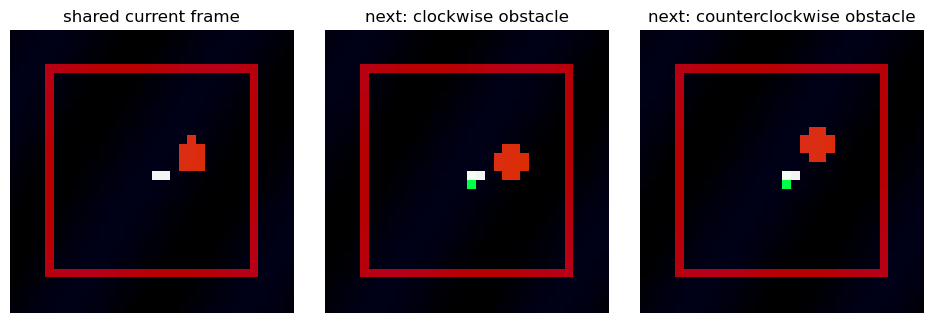

{'status': 'THIRD-DOMAIN ENGINEERING ALIAS SMOKE — NOT PERFORMANCE EVIDENCE',
 'task': 'controlled_dubins_navigation_pixels',
 'single_frame_equal': True,
 'two_frame_features_distinct': True,
 'hidden_quantity': 'obstacle_direction',
 'known_dynamics_only': True}

In [6]:
clockwise = DubinsState(
    x=0.0,
    y=-0.10,
    heading=0.0,
    obstacle_phase=0.4,
    obstacle_direction=-1,
    nuisance_phase=0.2,
)
counterclockwise = dataclasses.replace(clockwise, obstacle_direction=1)
clockwise_pixels = render_state(clockwise, config.data)
counterclockwise_pixels = render_state(counterclockwise, config.data)
clockwise_next = deterministic_step(clockwise, 0.0, config.data)
counterclockwise_next = deterministic_step(counterclockwise, 0.0, config.data)

h1 = dataclasses.replace(config.data, history_length=1)
h2 = dataclasses.replace(config.data, history_length=2)
assert clockwise_pixels == counterclockwise_pixels
assert observation_feature_vector((clockwise,), 0, h1) == observation_feature_vector(
    (counterclockwise,), 0, h1
)
assert observation_feature_vector((clockwise, clockwise_next), 1, h2) != observation_feature_vector(
    (counterclockwise, counterclockwise_next), 1, h2
)

def image_from_pixels(pixels):
    image = np.asarray(pixels).reshape(
        config.data.channels,
        config.data.image_size,
        config.data.image_size,
    )
    return np.moveaxis(image, 0, -1)

fig, axes = plt.subplots(1, 3, figsize=(9.6, 3.2))
axes[0].imshow(image_from_pixels(clockwise_pixels), vmin=0.0, vmax=1.0)
axes[0].set_title("shared current frame")
axes[1].imshow(image_from_pixels(render_state(clockwise_next, config.data)), vmin=0.0, vmax=1.0)
axes[1].set_title("next: clockwise obstacle")
axes[2].imshow(image_from_pixels(render_state(counterclockwise_next, config.data)), vmin=0.0, vmax=1.0)
axes[2].set_title("next: counterclockwise obstacle")
for axis in axes:
    axis.axis("off")
fig.tight_layout()
plt.show()

display({
    "status": "THIRD-DOMAIN ENGINEERING ALIAS SMOKE — NOT PERFORMANCE EVIDENCE",
    "task": config.data.task,
    "single_frame_equal": clockwise_pixels == counterclockwise_pixels,
    "two_frame_features_distinct": True,
    "hidden_quantity": "obstacle_direction",
    "known_dynamics_only": True,
})

## Takeaways

The real configured profile split, exact 200-bundle boundary, validation-only mass-matched radius
choice, scalar/tensor categorical target parity, deterministic FCSRL batch plan, and Dubins
observation/history interface all execute deterministically. They validate protocol wiring and a
third-domain engineering fixture only. No teacher was trained, no learned arm was evaluated, no raw
safety endpoint is promoted, and no result is eligible for the manuscript from this notebook.